## 1) Import & Display Options
---

In [2]:
import numpy as np
import pandas as pd

# Viz
import matplotlib.pyplot as plt
import seaborn as sns

# Pretty plots
plt.style.use('seaborn-v0_8')
sns.set_context('notebook')

# Pandas display
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

## 2) Load Titanic Passengers Data
---

In [3]:
df = pd.read_csv('C:/data/GitHub/BZIA_VM/DS/Titanic2026.csv')
print('Rows, Columns:', df.shape)
df.head()

Rows, Columns: (1317, 9)


,ID,LastName,FirstName,Title,Gender,Boarded,Class,Age,Survived
0,1,Ab i-Al-Munà,Nasif Qasim,Mr,M,Cherbourg,3rd,26.0,Yes
1,2,Abbing,Anthony,Mr,M,Southampton,3rd,42.0,No
2,3,Abbott,Rhoda Mary “Rosa”,Mrs,F,Southampton,3rd,39.0,Yes
3,4,Abbott,Rossmore Edward,Mr,M,Southampton,3rd,16.0,No
4,5,Abbott,Eugene Joseph,Mr,M,Southampton,3rd,14.0,No


## 3) Data and Type Check
---

In [3]:
# print the types of each feature

ID             int64
LastName      object
FirstName     object
Title         object
Gender        object
Boarded       object
Class         object
Age          float64
Survived      object
dtype: object


In [4]:
print(df.dtypes)

ID             int64
LastName      object
FirstName     object
Title         object
Gender        object
Boarded       object
Class         object
Age          float64
Survived      object
dtype: object


In [4]:
# Print the df columns

Index(['ID', 'LastName', 'FirstName', 'Title', 'Gender', 'Boarded', 'Class', 'Age', 'Survived'], dtype='object')


In [5]:
print(df.columns)

Index(['ID', 'LastName', 'FirstName', 'Title', 'Gender', 'Boarded', 'Class', 'Age', 'Survived'], dtype='object')


In [5]:
# Unique values for key features
### NOTE ### You don't have to do it in this exact output - can you get the answers?



Gender → ['M' 'F']

Boarded → ['Cherbourg' 'Southampton' 'Belfast' 'Queenstown']

Class → ['3rd' '2nd' '1st']

Survived → ['Yes' 'No']

Title → ['Mr' 'Mrs' 'Miss' 'Master' 'Colonel' 'Mme.' 'Reverend' 'Dr' 'Major'
 'Father' 'Captain' 'Sir' 'Lady' 'Señora' 'Mlle' 'Ms' 'Doña' 'Señor'
 'Countess' 'Don.']


In [6]:
for col in ['Gender', 'Boarded', 'Class', 'Survived', 'Title']:
    print(f"{col} → {df[col].unique()}\n")


Gender → ['M' 'F']

Boarded → ['Cherbourg' 'Southampton' 'Belfast' 'Queenstown']

Class → ['3rd' '2nd' '1st']

Survived → ['Yes' 'No']

Title → ['Mr' 'Mrs' 'Miss' 'Master' 'Colonel' 'Mme.' 'Reverend' 'Dr' 'Major'
 'Father' 'Captain' 'Sir' 'Lady' 'Señora' 'Mlle' 'Ms' 'Doña' 'Señor'
 'Countess' 'Don.']



In [7]:

result = pd.DataFrame({
    "Gender_count": df["Gender"].value_counts(),
    "Gender_percent": (df["Gender"].value_counts(normalize=True) * 100).round(1)
})
result.index.name = "Gender"
result = result.loc[["M", "F"]]  # optional: order rows
result



,Gender_count,Gender_percent
Gender,,
M,851,64.6
F,466,35.4


In [8]:
result = pd.DataFrame({
    "Boarded_count": df["Boarded"].value_counts(),
    "Boarded_percent": (df["Boarded"].value_counts(normalize=True) * 100).round(1)
})
result.index.name = "Boarded"
result

,Boarded_count,Boarded_percent
Boarded,,
Southampton,912,69.2
Cherbourg,272,20.7
Queenstown,123,9.3
Belfast,10,0.8


In [9]:
result = pd.DataFrame({
    "Class_count": df["Class"].value_counts(),
    "Class_percent": (df["Class"].value_counts(normalize=True) * 100).round(1)
})
result.index.name = "Class"
result

,Class_count,Class_percent
Class,,
3rd,709,53.8
1st,324,24.6
2nd,284,21.6


In [10]:
result = pd.DataFrame({
    "Survived_count": df["Survived"].value_counts(),
    "Survived_percent": (df["Survived"].value_counts(normalize=True) * 100).round(1)
})
result.index.name = "Survived"
result

,Survived_count,Survived_percent
Survived,,
No,833,63.2
Yes,484,36.8


In [11]:
result = pd.DataFrame({
    "Title_count": df["Title"].value_counts(),
    "Title_percent": (df["Title"].value_counts(normalize=True) * 100).round(1)
})
result.index.name = "Title"
result

,Title_count,Title_percent
Title,,
Mr,765,58.1
Miss,257,19.5
Mrs,198,15.0
Master,61,4.6
Dr,8,0.6
Father,6,0.5
Colonel,4,0.3
Señora,3,0.2
Reverend,2,0.2


In [6]:
# Extended to include counts:
### NOTE ### You don't have to do it in this exact output - can you get the answers?


=== Gender ===


,Gender_count,Gender_percent
Gender,,
M,851,64.6
F,466,35.4



=== Boarded ===


,Boarded_count,Boarded_percent
Boarded,,
Southampton,912,69.2
Cherbourg,272,20.7
Queenstown,123,9.3
Belfast,10,0.8



=== Class ===


,Class_count,Class_percent
Class,,
3rd,709,53.8
1st,324,24.6
2nd,284,21.6



=== Survived ===


,Survived_count,Survived_percent
Survived,,
No,833,63.2
Yes,484,36.8



=== Title ===


,Title_count,Title_percent
Title,,
Mr,765,58.1
Miss,257,19.5
Mrs,198,15.0
Master,61,4.6
Dr,8,0.6
Father,6,0.5
Colonel,4,0.3
Señora,3,0.2
Major,2,0.2


## 4) Check for and Dealing with NaNs
---
- Delete the rows?
- Impute values?

In [12]:
null_count = df.isnull().sum()
result = null_count.to_frame(name="null_count")
result = result.sort_values(by="null_count", ascending=False)
result

,null_count
Age,2
ID,0
LastName,0
FirstName,0
Title,0
Gender,0
Boarded,0
Class,0
Survived,0


In [13]:
val = (df["Age"].isnull().mean() * 100).round(1)
result = pd.DataFrame({"null_percent": [val]}, index=["Age"])
result.index.name = None  # optional
result


,null_percent
Age,0.2


In [14]:

rows_with_null = df[df.isnull().any(axis=1)]

# 2) Choose how many to show (like your screenshot shows “up to 20”)
N = 20
count = len(rows_with_null)

# 3) Print a friendly header, then display the first N rows
print(f"Rows with at least one null: {count} (showing up to {N})")

# Don’t use print(); let Jupyter render the nice HTML table:
rows_with_null.head(N)
'''
What each part does

df.isnull().any(axis=1) → a boolean Series that’s True for rows where any column is null.
df[ ... ] → filters the DataFrame to only those rows.
len(rows_with_null) → total number of rows containing missing values.
head(N) → shows only the first N rows to keep the output tidy.
Leaving the DataFrame (rows_with_null.head(N)) to show the table results
'''

Rows with at least one null: 2 (showing up to 20)


'\nWhat each part does\n\ndf.isnull().any(axis=1) → a boolean Series that’s True for rows where any column is null.\ndf[ ... ] → filters the DataFrame to only those rows.\nlen(rows_with_null) → total number of rows containing missing values.\nhead(N) → shows only the first N rows to keep the output tidy.\nLeaving the DataFrame (rows_with_null.head(N)) to show the table results\n'

In [44]:
# 1) Count of nulls per column

# 2) Percent of nulls per column (only columns that have any nulls)


# 3) Preview of rows that contain at least one null


In [15]:

import pandas as pd

df = pd.read_csv("Titanic2026.csv", skipinitialspace=True)

mask = (
    (df["Gender"] == "M") &
    (df["Class"] == "3rd") &
    (df["Boarded"] == "Cherbourg") &
    (df["Survived"] == "No")
)
sub = df.loc[mask]

# 1) Your 56 (all rows in the subgroup)
subgroup_count_all = len(sub)

# 2) Teacher’s 54 (only rows with non-null Age)
subgroup_count_with_age = sub["Age"].notna().sum()

# 3) Missing-age rows in that subgroup (for verification)
missing_age_rows = sub.loc[sub["Age"].isna(), ["ID", "LastName", "FirstName", "Age"]]

print("Subgroup Count (all):", subgroup_count_all)          # 56
print("Subgroup Count (Age present):", subgroup_count_with_age)  # 54
print("\nMissing Age in subgroup:\n", missing_age_rows)


Subgroup Count (all): 56
Subgroup Count (Age present): 54

Missing Age in subgroup:
       ID    LastName FirstName  Age
439  440  Gheorgheff    Stanio  NaN
675  676      Kraeff   Theodor  NaN


In [16]:

mask = (
    (df["Gender"] == "M") &
    (df["Class"] == "3rd") &
    (df["Boarded"] == "Cherbourg") &
    (df["Survived"] == "No")
)

sub = df.loc[mask]  # this is your subgroup view

subgroup_count = sub["Age"].notna().sum()
print(f"Subgroup Count: {subgroup_count}")


size = sub["Age"].shape[0]                # number of rows in the subgroup
mean_age = sub["Age"].mean()              # NaNs ignored by default
median_age = sub["Age"].median()          # NaNs ignored by default

print("\n# Show the stats for each defined subgroup\n")
print(f"Subgroup size: {size}")
print(f"Mean Age: {mean_age:.2f}")
print(f"Median Age: {median_age:.2f}")

median_age = sub["Age"].median()
df.loc[mask, "Age"] = df.loc[mask, "Age"].where(df.loc[mask, "Age"].notna(), median_age)
median_age

Subgroup Count: 54

# Show the stats for each defined subgroup

Subgroup size: 56
Mean Age: 25.09
Median Age: 25.00


25.0

In [8]:
# Delete rows OR define the subgroup to determine a realistic median or mean to impute:

# Define subgroup: Male, 3rd class, Cherbourg, Survived = No


Subgroup Count: 54


In [24]:
# Show the stats for each defined subgroup


Subgroup size: 54
Mean Age: 25.09
Median Age: 25.00


In [10]:
# Impute missing Age with median (common practice)



## 5) Basic Cleaning:
--- 
- trim spaces
- standardize cases
- fix numerics AS *numeric*

In [58]:
# Strip leading/trailing spaces in all object columns
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

In [12]:
# Standardize categorical case (title case for names, upper/lower for codes)
for c in ['Gender', 'Boarded', 'Class', 'Survived', 'Title']:
    if c in df.columns:
        df[c] = df[c].str.strip()

In [14]:
# Age to numeric (coerce non-numeric to NaN)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

In [15]:
# Quick check of missing values (post-clean)  (i.e. if any Ages were changed to NaN with coerce they would show here)


ID           0
LastName     0
FirstName    0
Title        0
Gender       0
Boarded      0
Class        0
Age          0
Survived     0
dtype: int64

## 6) Create Helper Features (for Analysis)
---

- Child under 12
- Passenger groupings
- Encode to binary
  - Survival (Yes -> 1, No -> 0)
- Encode to ordinal
  - Class (1st -> 1, 2nd - > 2, etc)
- Encode to short codes
  - Boarded (Cherbourg -> C, Southhampton -> S, etc)


In [19]:
# Is child (under 12)? (Common Titanic framing)
# See output from code below df.head() below for helper feature names

# Is child (under 12)?
df["IsChild"] = df["Age"].lt(12)




df["Survived_bin"] = df["Survived"].map({
    "Yes": 1,
    "No": 0
})


df["Class_num"] = df["Class"].map({
    "1st": 1,
    "2nd": 2,
    "3rd": 3
})


df["Embark"] = df["Boarded"].map({
    "Cherbourg": "C",
    "Southampton": "S",
    "Queenstown": "Q"
})


df["Gender_bin"] = df["Gender"].map({
    "M": 1,
    "F": 0
})


In [20]:
df.head()

,ID,LastName,FirstName,Title,Gender,Boarded,Class,Age,Survived,IsChild,Survived_bin,Class_num,Embark,Gender_bin
0,1,Ab i-Al-Munà,Nasif Qasim,Mr,M,Cherbourg,3rd,26.0,Yes,False,1,3,C,1
1,2,Abbing,Anthony,Mr,M,Southampton,3rd,42.0,No,False,0,3,S,1
2,3,Abbott,Rhoda Mary “Rosa”,Mrs,F,Southampton,3rd,39.0,Yes,False,1,3,S,0
3,4,Abbott,Rossmore Edward,Mr,M,Southampton,3rd,16.0,No,False,0,3,S,1
4,5,Abbott,Eugene Joseph,Mr,M,Southampton,3rd,14.0,No,False,0,3,S,1


## 7) Basic Survival Stats
---

In [32]:

# Is child (under 12)? (Common Titanic framing)
df["IsChild"] = (df["Age"] < 12).fillna(False)

# Passenger Full Name
df["NameFull"] = (
    df["Title"].fillna("") + " " +
    df["FirstName"].fillna("") + " " +
    df["LastName"].fillna("")
)

# Encode Survived to binary (Yes=1, No=0)
df["Survived_bin"] = df["Survived"].map({
    "Yes": 1,
    "No": 0
})

# Simplify Class to ordinal (1st=1, 2nd=2, 3rd=3)
df["Class_num"] = df["Class"].map({
    "1st": 1,
    "2nd": 2,
    "3rd": 3
})

# Embark port short codes based on Boarded text
df["Embark"] = df["Boarded"].map({
    "Cherbourg": "C",
    "Southampton": "S",
    "Queenstown": "Q",
    "Belfast": "B"
})

In [23]:
### NOTE ### You don't have to do it in this exact output - can you get the answers?

# Overall survival rate

# Overall survival rate
overall = df["Survived_bin"].mean()

# Grouped survival rates
by_gender = (
    df.groupby("Gender")["Survived_bin"]
      .mean()
      .sort_values(ascending=False)
)

by_class = (
    df.groupby("Class")["Survived_bin"]
      .mean()
      .sort_values(ascending=False)
)

by_port = (
    df.groupby("Boarded")["Survived_bin"]
      .mean()
      .sort_values(ascending=False)
)

by_child = (
    df.groupby("IsChild")["Survived_bin"]
      .mean()
)

# Print formatted results
print("Overall survival rate:", f"{overall * 100:.2f}%")

print("\nBy Gender:\n", (by_gender * 100).round(1).astype(str) + "%")

print("\nBy Class:\n", (by_class * 100).round(1).astype(str) + "%")

print("\nBy Boarding Port:\n", (by_port * 100).round(1).astype(str) + "%")

print("\nChildren vs Adults:\n", (by_child * 100).round(1).astype(str) + "%")


Overall survival rate: 36.75%

By Gender:
 Gender
F    69.3%
M    18.9%
Name: Survived_bin, dtype: object

By Class:
 Class
1st    62.0%
2nd    39.1%
3rd    24.3%
Name: Survived_bin, dtype: object

By Boarding Port:
 Boarded
Cherbourg      55.9%
Southampton    32.1%
Queenstown     31.7%
Belfast         0.0%
Name: Survived_bin, dtype: object

Children vs Adults:
 IsChild
False    35.3%
True     52.8%
Name: Survived_bin, dtype: object


## 8) Visualize Survival Rate
---
by Gender and Class

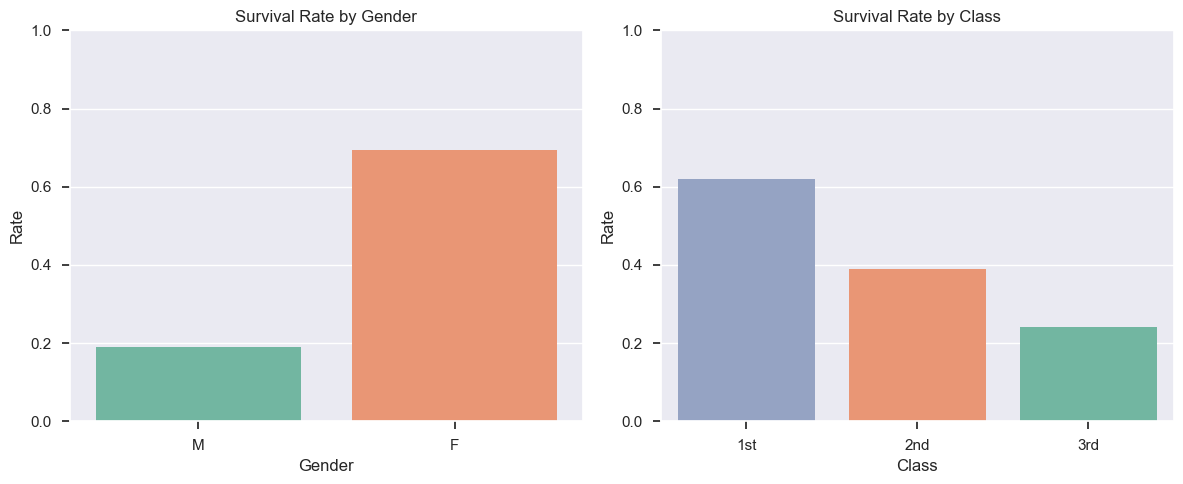

In [26]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: by Gender ---
sns.barplot(
    data=df,
    x="Gender", y="Survived_bin",
    hue="Gender",
    estimator=np.mean,
    errorbar=None,
    ax=axes[0],
    palette="Set2",
    legend=False
)

axes[0].set_title("Survival Rate by Gender")
axes[0].set_ylabel("Rate")
axes[0].set_xlabel("Gender")
axes[0].set_ylim(0, 1)


# --- Right: by Class ---
sns.barplot(
    data=df,
    x="Class", y="Survived_bin",
    hue="Class",
    estimator=np.mean,
    errorbar=None,
    ax=axes[1],
    palette="Set2",
    legend=False,
    order=["1st", "2nd", "3rd"]
)

axes[1].set_title("Survival Rate by Class")
axes[1].set_ylabel("Rate")
axes[1].set_xlabel("Class")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()




## 9) Age Distibutions
---

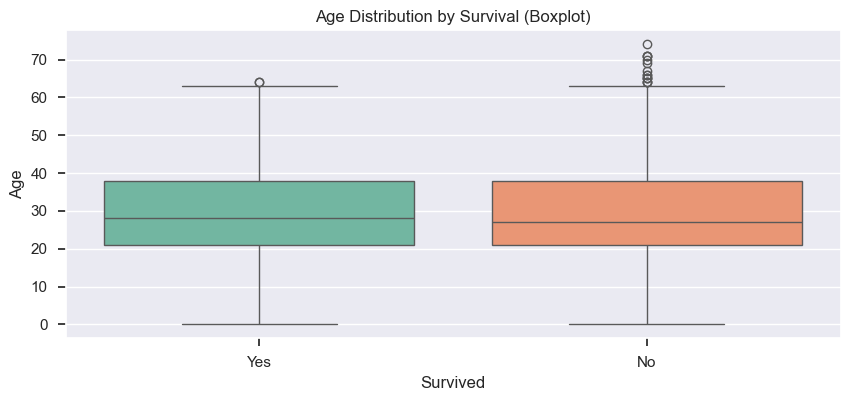

Text(0.5, 1.0, 'Age Distribution by Survival')

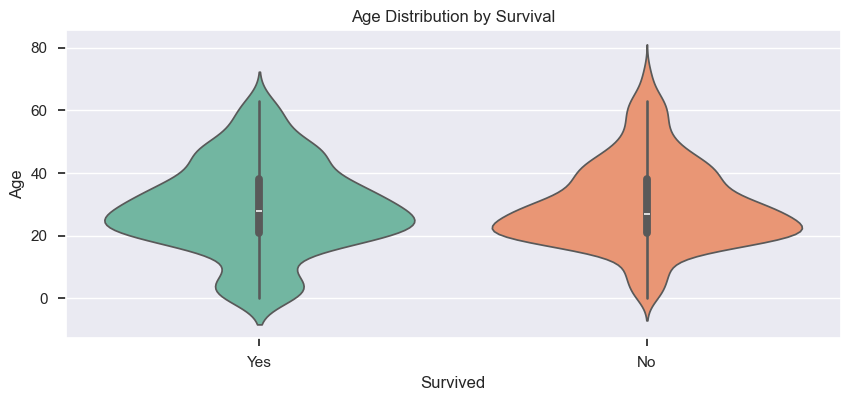

In [27]:

import matplotlib.pyplot as plt
import seaborn as sns

# --- Boxplot ---
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=df,
    x="Survived", y="Age",
    palette="Set2",
    hue="Survived"
)
plt.title("Age Distribution by Survival (Boxplot)")
plt.ylabel("Age")
plt.xlabel("Survived")
plt.show()


# --- Violin plot ---
plt.figure(figsize=(10, 4))
sns.violinplot(
    data=df,
    x="Survived", y="Age",
    split=False,
    inner="box",
    palette="Set2",
    hue="Survived"
)
plt.title("Age Distribution by Survival")


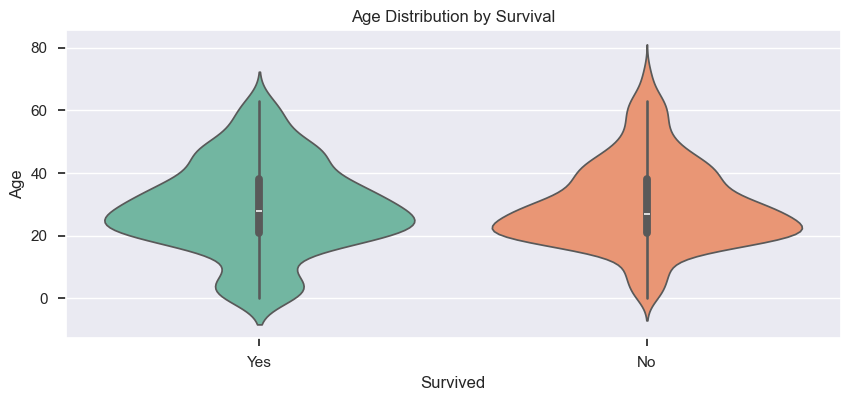

In [28]:
# Violin plot alternative

plt.figure(figsize=(10, 4))
sns.violinplot(
    data=df,
    x="Survived", y="Age",
    split=False,
    inner="box",
    palette="Set2",
    hue="Survived"
)
plt.title("Age Distribution by Survival")
plt.show()


## 10) Survival by Key Features
---
Utilitizing Crosstabs

In [29]:
### NOTE ### You don't have to do it in this exact output - can you get the answers?


ct_gender_class = pd.crosstab(
    df["Gender"], df["Class"],
    values=df["Survived_bin"],
    aggfunc="mean"
).round(3)

ct_port_class = pd.crosstab(
    df["Boarded"], df["Class"],
    values=df["Survived_bin"],
    aggfunc="mean"
).round(3)

ct_child_class = pd.crosstab(
    df["IsChild"], df["Class"],
    values=df["Survived_bin"],
    aggfunc="mean"
).round(3)

print("Survival rate (mean) by Gender & Class:\n", ct_gender_class, "\n")
print("Survival rate (mean) by Boarded & Class:\n", ct_port_class, "\n")
print("Survival rate (mean) for Children & Class:\n", ct_child_class, "\n")


Survival rate (mean) by Gender & Class:
 Class     1st    2nd    3rd
Gender                     
F       0.965  0.821  0.449
M       0.344  0.135  0.152 

Survival rate (mean) by Boarded & Class:
 Class          1st    2nd    3rd
Boarded                         
Belfast      0.000  0.000    NaN
Cherbourg    0.715  0.538  0.343
Queenstown   0.667  0.286  0.310
Southampton  0.555  0.388  0.206 

Survival rate (mean) for Children & Class:
 Class      1st   2nd    3rd
IsChild                    
False    0.618  0.34  0.225
True     0.800  1.00  0.380 



In [3]:
!pip install ydata-profiling